## Matching template -- EMRI 7
Structured notebook to compare EMRI simulated data to fast template.

In [1]:
# imports
import os
os.environ["GPUBACKENDTOOLS_FORCE_BACKEND"] = "cuda12x"

from fastlisaresponse import ResponseWrapper, pyResponseTDI

In [2]:
from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral

from lisatools.detector import Orbits
from lisaconstants import ASTRONOMICAL_YEAR

import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
import pandas as pd
import os
import h5py
from scipy.signal.windows import tukey
from h5py import File
from lisaconstants import ASTRONOMICAL_YEAR
from lisaorbits import OEMOrbits

from scipy.interpolate import CubicSpline

from lisatools.detector import EqualArmlengthOrbits, Orbits
from lisatools.utils.utility import AET

from fastlisaresponse.utils.parallelbase import FastLISAResponseParallelModule
YRSID_SI = ASTRONOMICAL_YEAR
from fastlisaresponse import pyResponseTDI

from multiprocessing.sharedctypes import Value
import numpy as np
from typing import Optional, List
import warnings
from typing import Tuple
from copy import deepcopy

import time
import h5py

### Load the correct L1 file and timing parameters
Load XYZ channels and timing params to build custom EMRI object.

In [3]:
source_index = 7

In [4]:
from mojito import MojitoL1File

scratch = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/L1'
L1_file_path = f'{scratch}/EMRI_731d_2.5s_L1_source7_0_20251203T231827138749Z.h5'
    
with MojitoL1File(L1_file_path) as f:

    # Timing parameters
    # l01_t0 = f['tdis/sampling'].attrs['t0']
    # l01_dt = f['tdis/sampling'].attrs['dt']
    # l01_size = f['tdis/sampling'].attrs['size']
    
    tdi_time_sampling = f.tdis.time_sampling
    tdi_dt = tdi_time_sampling.dt
    
    # TDI observables
    CENTRAL_FREQ = f.laser_frequency
    print(CENTRAL_FREQ)
    
    x2 = f.tdis.x2[:] / CENTRAL_FREQ  # TDI X2 observable in Hz
    y2 = f.tdis.y2[:] / CENTRAL_FREQ # TDI Y2 observable in Hz
    z2 = f.tdis.z2[:] / CENTRAL_FREQ # TDI Z2 observable in Hz
    

281600000000000.0


In [5]:
x2[:20]

array([-2.38098213e-25, -2.85326862e-25, -3.11951324e-25, -3.16221358e-25,
       -2.97990159e-25, -2.58713400e-25, -2.01334010e-25, -1.30061751e-25,
       -5.00640899e-26,  3.29089059e-26,  1.12938392e-25,  1.84359472e-25,
        2.42162593e-25,  2.82345146e-25,  3.02188574e-25,  3.00441818e-25,
        2.77398755e-25,  2.34864956e-25,  1.76017033e-25,  1.05165485e-25])

In [6]:
dt = delta_t = tdi_dt
tdi_dt

2.5

In [7]:
x2.shape

(25246480,)

In [8]:
len_waveform = int(x2.shape[0] + 2* (550/dt + 1000))
len_waveform

25248920

In [9]:
Time = len_waveform / ASTRONOMICAL_YEAR *dt

In [10]:
Time

2.000190140200036

### Define timing grid
Build the correct timing grid and set parameters based on the L1 file.

In [11]:
tdi_time_sampling.t0

97729939.827664

In [12]:
def get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse,
    ) -> dict:
        """This function derives all timings relevant for Mojito, and generates the
        orbits file and groundtracking file.
        """
        # round up to integer multiple of `dt`
        duration_mojito_light = np.ceil(2.0 * ASTRONOMICAL_YEAR / dt) * dt

        # time reference from orbits file
        orbits = OEMOrbits.from_included(oemorbits)
        t0_orbits = float(orbits.t_start) + t_dltt_orbits

        # sizes: L1 has "+1" to cover full 2-year extent
        size_l1 = int(np.round(duration_mojito_light / dt)) + 1
        size_l0 = size_l1 + 2 * n_trim_lolipops
        size_strain = size_l0 + int(2 * np.ceil(t_strain_offset / dt))
        size_orbits = (
            int(
                np.ceil(((1 + 2 * window_jaxgbresponse) * size_l0 - 1) * dt / dt_orbits)
            )
            + 1
            + 2 * n_orbit_buffer
        )

        # time definitions
        t0_l0 = (
            t0_orbits + n_orbit_buffer * dt_orbits + window_jaxgbresponse * size_l0 * dt
        )
        t_init = t0_l0 - t_strain_offset
        timing_dict = {
            "dt": dt,
            "t_dltt_orbits": t_dltt_orbits,
            "dt_orbits": dt_orbits,
            "t_strain_offset": t_strain_offset,
            "n_trim_lolipops": n_trim_lolipops,
            "n_orbit_buffer": n_orbit_buffer,
            "window_jaxgbresponse": window_jaxgbresponse,
            "t0_orbits": t0_orbits,
            "size_l1": size_l1,
            "size_l0": size_l0,
            "size_strain": size_strain,
            "size_orbits": size_orbits,
            "t0_l0": t0_l0,
            "t_init": t_init,
        }
        return timing_dict

def create_orbits(oemorbits, timing, dense_orbits_path) -> None:
        """Create orbits file"""
        orbits = OEMOrbits.from_included(oemorbits)
        orbits.write(
            dense_orbits_path,    
            dt=timing["dt_orbits"],   
            size=timing["size_orbits"],
            t0=timing["t0_orbits"],
            mode="w",
        )


In [13]:
# create timing dictionary

t_dltt_orbits = 10.
dt_orbits = 5e5
t_strain_offset = 550
n_trim_lolipops = 1000
n_orbit_buffer = 10
window_jaxgbresponse = 0.5 

oemorbits =  "esa-trailing"

In [14]:
dt_orbits

500000.0

In [15]:
timing = get_mojito_timing(
        oemorbits,
        dt,
        t_dltt_orbits,
        dt_orbits,
        t_strain_offset,
        n_trim_lolipops,
        n_orbit_buffer,
        window_jaxgbresponse)

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [16]:
timing

{'dt': 2.5,
 't_dltt_orbits': 10.0,
 'dt_orbits': 500000.0,
 't_strain_offset': 550,
 'n_trim_lolipops': 1000,
 'n_orbit_buffer': 10,
 'window_jaxgbresponse': 0.5,
 't0_orbits': 61171239.327664,
 'size_l1': 25246521,
 'size_l0': 25248521,
 'size_strain': 25248961,
 'size_orbits': 274,
 't0_l0': 97731890.577664,
 't_init': 97731340.577664}

In [17]:
tdi_time_sampling.t0

97729939.827664

In [18]:
timing['t0_l0'] - 550

97731340.577664

In [19]:
timing['t0_l0'] - 550 - tdi_time_sampling.t0

1400.75

### Build waveform object
Build a waveform object that injects the EMRI at the correct frequency. 

In [20]:
from fastlisaresponse.utils.parallelbase import ParallelModuleBase
# Create EMRIWave object
sum_kwargs = {
    "pad_output": True,
}

inspiral_kwargs = {
    "DENSE_STEPPING": 0,  # sparsely sampled trajectory
    "max_init_len": int(1e8),  # length of trajectories well under 1000
}

amplitude_kwargs = {
    # "max_init_len": int(1e8),  # all of the trajectories will be well under len = 1000
    # "use_gpu": True,
    # "file_dir":"/data/leuven/367/vsc36785/LISA/FastEMRIWaveforms/data"
}

waveform_kwargs = {
    'mode_selection_threshold': 0.0
}

In [43]:
class EMRIWave(ParallelModuleBase):
    def __init__(self, force_backend=None, 
                use_gpu=True, 
                 T_smooth=0, 
                 model='Kerr',
                 inspiral_kwargs=inspiral_kwargs,
                 sum_kwargs=sum_kwargs,
                 amplitude_kwargs=amplitude_kwargs,
                 mode_selection_threshold=1e-5,
                 t_init=33568152.5,
                 t0_orbits=33568152.5,
                 dt=5, 
                 n_samples=1000,
                 offset=550, # seconds
                 strain_only=False,
                 time=2.0
                #  tdi_offset=250  # seconds
                ):
                 
        super().__init__(force_backend=force_backend)
        
        self.use_gpu = use_gpu
        self.T_smooth = T_smooth
        self.model = model
        self.mode_threshold = mode_selection_threshold
        
        # Initialize waveform generator
        if self.model == 'Kerr':
            self.waveform_gen = GenerateEMRIWaveform(
                "FastKerrEccentricEquatorialFlux",
                return_list=False,    # returns hp - i*hx as a complex cupy array
                inspiral_kwargs=inspiral_kwargs,
                sum_kwargs=sum_kwargs,
                amplitude_kwargs=amplitude_kwargs,
                frame="detector"
            )
        elif self.model == 'AAK':
            self.waveform_gen = GenerateEMRIWaveform(
                    'Pn5AAKWaveform',
                    return_list=False,
                    inspiral_kwargs=inspiral_kwargs,
                    sum_kwargs=sum_kwargs,
                    frame='detector'
            )
        else: 
            raise ValueError(f'{self.model} is not valid. Options are Kerr and AAK') 
            
        # get smooth window function 
        if T_smooth != 0.0:
            self.num_pts = int(self.T_smooth/dt)
            self.window = cp.asarray(tukey(2*self.num_pts, alpha=1, sym=True)[self.num_pts:])
    
        self.dt = dt 
        # define timing
        self.strain_only = strain_only
        if strain_only == True:
            self.n_samples = 0
            self.t0_flr = 0
            self.offset = 0
            self.time = None
        else:
            self.initial_zeros = cp.zeros(int(
                np.ceil((t_init - t0_orbits)/dt)
                ))
            
            self.n_samples = n_samples
            self.offset = offset
            self.time = time
    
    
    @classmethod
    def supported_backends(cls):
        return ["fastlisaresponse_" + _tmp for _tmp in cls.GPU_RECOMMENDED()]
    
    @property
    def initial_zeros_length(self):
        return len(self.initial_zeros)

    def __call__(self, *params, T=2, dt=5):
        '''
        Call FEW waveform model and return the strain as h_+ - ih_x
        '''
        if self.time is not None:
            Tobs = self.time
        else:
            Tobs = T

        # define correct time grid for waveform generation.
        waveform_kwargs['T'] = Tobs
        waveform_kwargs['dt'] = dt
        waveform_kwargs['mode_selection_threshold'] = self.mode_threshold
        strain = self.waveform_gen(*params, **waveform_kwargs)

        if self.T_smooth != 0.0:
            padding_index = self.get_pad_index(strain)
            if padding_index != len(strain):
                start_ind = padding_index-self.num_pts
                end_ind = padding_index 
                strain[start_ind:end_ind] = strain[start_ind:end_ind] * self.window
        if self.strain_only:
            # return strain generated for the requested time window
            return strain
        else:
            # return strain on a larger time grid for compatibility with response computation
            
            initial_strains = cp.concatenate((self.initial_zeros, strain, self.initial_zeros), axis=0)
            return initial_strains
            # # pad the initial_strains array with zeros to ensure it is long enough for response computation
            # return cp.pad(initial_strains, (0, len(initial_strains)+ len(self.initial_zeros)), axis=0)

In [22]:
t0_l0 = tdi_time_sampling.t0
offset = 550 # seconds
# t_init = t0_l0 - offset
t_init = 97729089.327664

orbits = OEMOrbits.from_included(oemorbits)
t0_orbits = float(orbits.t_start) + t_dltt_orbits

n_samples = 1000 # necessary to do the TDI delays

use_gpu=True
t_smooth=0
waveform_model='Kerr'
mode_selection_threshold = 0.0

emri_waveform = EMRIWave(use_gpu=use_gpu, 
                         T_smooth=t_smooth, 
                         model=waveform_model,
                         mode_selection_threshold=mode_selection_threshold,
                         strain_only=False,
                         t0_orbits=t0_orbits,
                         t_init=t_init,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=offset, # seconds
                         time=Time   # time for which we generate the waveform
                        )

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [23]:
np.ceil((t_init - t0_orbits)/dt)

np.float64(14623140.0)

In [24]:
cp.zeros(int(np.ceil((t_init - t0_orbits)/dt)))

array([0., 0., 0., ..., 0., 0., 0.], shape=(14623140,))

In [25]:
f_s = 1/dt   
home_folder = os.getcwd()
orbit_file = f'{home_folder}/orbits/esa-trailing-orbits-mojito_validation_test_2.h5'

force_backend = "cuda12x" if use_gpu else None

index_beta = 8
index_lambda = 7

tdi_kwargs = {
    'tdi': '2nd generation',
    'tdi_chan': 'XYZ',
    'order': 39,
}

In [26]:
T = 2.0  # years
t0 = 10000.0  # time at which signal starts (chops off data at start of waveform where information is not correct)

### Get source parameters
Load the EMRI catalog and unpack the specifc source parameters

In [27]:
# # Load EMRI parameters from source catalog. 
# home_folder = os.getcwd()

# EMRI_sources_path = f'{home_folder}/mojito_catalog_standardized_processed.hdf5'
# with h5py.File(EMRI_sources_path) as hf:
#             M = hf['Binaries']['PrimaryMassSSBFrame'][source_index]
#             mu = hf['Binaries']['SecondaryMassSSBFrame'][source_index]
#             a = hf['Binaries']['PrimarySpinParameter'][source_index]
#             p0 = hf['Binaries']['SemiLatusRectum'][source_index]
#             e0 = hf['Binaries']['Eccentricity'][source_index]
#             inclination = hf['Binaries']['InclinationAngle'][source_index]
#             dist = hf['Binaries']['LuminosityDistance'][source_index] * 1e-3 # convert to Gpc as FEW wants
#             ra = hf['Binaries']['RightAscension'][source_index]
#             dec = hf['Binaries']['Declination'][source_index]
#             qK = hf['Binaries']['PolarAnglePrimarySpin'][source_index]
#             phiK = hf['Binaries']['AzimuthalAnglePrimarySpin'][source_index]
#             Phi_phi0 = hf['Binaries']['AzimuthalPhase'][source_index]
#             Phi_theta0 = hf['Binaries']['PolarPhase'][source_index]
#             Phi_r0 = hf['Binaries']['RadialPhase'][source_index]
#             z = hf['Binaries']['Redshift'][source_index]

In [28]:
# print(f'''
#             M = {M}
#             mu = {mu}
#             a = {a}
#             p0 =  {p0}
#             e0 = {e0}
#             inclination = {np.cos(inclination)}
#             dist = {dist}
#             ra = {ra}
#             dec = {dec}
#             qK = {qK}
#             phiK = {phiK}
#             Phi_phi0 = {Phi_phi0}
#             Phi_theta0 = {Phi_theta0}
#             Phi_r0 = {Phi_r0}
#             z = {z}
# ''')

In [30]:
from mojito.download import download_catalog

In [31]:
# Download mbhb catalog
catalog_path = download_catalog("emri", 
                                username='bert-depoorter',
                               token='2c7#QBB9DTh8QgJPpw')

WARNING! Publications using Mojito data are currently not allowed! Please keep in touch, as publication policies will soon be published.


In [32]:
from mojito.download import get_source_params

# Get source parameters for mbhb brick, source ID 12
params = get_source_params("emri", source_id=7, username='bert-depoorter', token='2c7#QBB9DTh8QgJPpw')

WARNING! Publications using Mojito data are currently not allowed! Please keep in touch, as publication policies will soon be published.


In [33]:
params

{'AzimuthalAnglePrimarySpin': np.float64(5.501703732600556),
 'AzimuthalPhase': np.float64(0.9670255899837221),
 'ChirpMassSSBFrame': np.float64(1511.6610912353246),
 'Declination': np.float64(-0.33905485719486705),
 'Eccentricity': np.float64(0.7694807418917016),
 'EstimatedSNR': np.float64(61.61161640625107),
 'ID': np.int64(8),
 'InclinationAngle': np.float64(0.0),
 'LuminosityDistance': np.float64(3714.12195945477),
 'MassRatio': np.float64(9.202129320913841e-05),
 'PolarAnglePrimarySpin': np.float64(1.2353252606186405),
 'PolarPhase': np.float64(0.9967613024379192),
 'PrimaryMassSSBFrame': np.float64(399143.8370943168),
 'PrimaryMassSourceFrame': np.float64(246263.47323100598),
 'PrimarySpinParameter': np.float64(0.9689),
 'RadialPhase': np.float64(1.2776797663052248),
 'Redshift': np.float64(0.6207999987066789),
 'RightAscension': np.float64(1.8810428183575403),
 'SecondaryMassSSBFrame': np.float64(36.7297320658767),
 'SecondaryMassSourceFrame': np.float64(22.66148327689121),
 'S

In [35]:
assert params['PrimaryMassSSBFrame'] == params['PrimaryMassSourceFrame']*(1 + params['Redshift'])
assert params['SecondaryMassSSBFrame'] == params['SecondaryMassSourceFrame']*(1 + params['Redshift'])

In [36]:
def icrs_to_ecliptic(ra, dec):
    """Convert ICRS coordinates (ra, dec) to ecliptic coordinates (lambda, beta)."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    icrs_coord = SkyCoord(ra=ra * u.rad, dec=dec * u.rad, frame='icrs')
    ecliptic_coord = icrs_coord.barycentrictrueecliptic

    lambda_ecl = ecliptic_coord.lon.rad
    beta_ecl = ecliptic_coord.lat.rad

    return lambda_ecl, beta_ecl

In [37]:
ra = params['RightAscension']
dec = params['Declination']

lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)
qS_ecl = np.pi / 2 - beta_ecl
phiS_ecl = lam_ecl


In [38]:
# extract source parameters
params_mojito = [
    params['PrimaryMassSSBFrame'],
    params['SecondaryMassSSBFrame'],
    params['PrimarySpinParameter'],
    params['SemiLatusRectum'],
    params['Eccentricity'],
    np.cos(params['InclinationAngle']),
    params['LuminosityDistance']*1e-3,
    qS_ecl,
    phiS_ecl,
    params['PolarAnglePrimarySpin'],
    params['AzimuthalAnglePrimarySpin'],
    params['AzimuthalPhase'],
    params['PolarPhase'],
    params['RadialPhase'],
]

### Convert angular coordinates

The switch from reference coordinate systems should not make a difference in the final TDI output. We have the polarization angle $\psi =-2.831678669421924$ in equatorial coordinate system. Now we should transform this angle to the ecliptic coordinate system. 

This is done in the following way, based on the conventions document. 
$$
\begin{align}
    \sin \beta &= \sin\delta \cos \epsilon - \cos\delta \sin \epsilon\sin\alpha\\
    \cos\lambda &= cos\alpha\cos\delta / \cos\beta \\
    \sin \lambda &= [\sin \delta\sin\epsilon+ \cos\delta\cos\epsilon\sin\alpha]/ \cos\beta
\end{align}
$$

For the polarization angle, we have $\psi_0$ is the polarization in the ecliptic reference frame and $\psi$ in the equatorial reference frame.

$$
\psi_0 = \delta_psi + \psi
$$

$$
    \cos\delta\psi = \frac{1}{\cos\beta}\big[\sin \epsilon\sin\delta\sin\alpha + \cos\epsilon\cos\delta\big]
$$
For consistency and sign checks we can use the following formulae:
$$
\begin{align}
    \sin\delta\psi &= -\frac{1}{\cos\beta}\sin\epsilon\cos\alpha\\
    \cos\delta\psi &= \frac{1}{\cos\delta}\big[ -\sin\epsilon\sin\beta\sin\lambda + \cos\epsilon\cos\beta\big] \\
    \sin\delta\psi &= -\frac{1}{\cos\delta}\sin\epsilon\cos\lambda
\end{align}
$$
We can implement this all in a function that does the conversion for us. For the equatorial obliquity, we use the $J2000.0$ equinox. This gives $\epsilon \simeq 23.4$ degrees.

In [37]:
# convert back to the qS / phiS in the catalog
def equatorial_to_ecliptic_psi(alpha, delta, epsilon=0.4090677):
    """
    Converts equatorial coordinates to ecliptic and transforms the GW polarization angle.
    
    Args:
        alpha (float): Right Ascension (radians)
        delta (float): Declination (radians)
        psi_equatorial (float): Polarization angle in equatorial frame (radians)
        epsilon (float): Obliquity of the ecliptic. Default is J2000 value (~23.44 deg).
        
    Returns:
        dict: lambda (long), beta (lat), and psi_ecliptic (radians)
    """
    # 1. Compute Ecliptic Latitude (beta)
    # sin(beta) = sin(delta)cos(eps) - cos(delta)sin(eps)sin(alpha)
    sin_beta = np.sin(delta) * np.cos(epsilon) - np.cos(delta) * np.sin(epsilon) * np.sin(alpha)
    beta = np.arcsin(sin_beta)
    cos_beta = np.cos(beta)

    # 2. Compute Ecliptic Longitude (lambda)
    # Use arctan2(sin, cos) for correct quadrant logic
    sin_lam = (np.sin(delta) * np.sin(epsilon) + np.cos(delta) * np.cos(epsilon) * np.sin(alpha)) / cos_beta
    cos_lam = (np.cos(alpha) * np.cos(delta)) / cos_beta
    lam = np.arctan2(sin_lam, cos_lam)

    return {
        "lambda": lam,
        "beta": beta,
    }

In [6]:
ecliptic_CO_loc =  equatorial_to_ecliptic_psi(ra, dec)
qS = np.pi/2 - ecliptic_CO_loc['beta']
phiS = ecliptic_CO_loc['lambda']

NameError: name 'ra' is not defined

In [43]:
ecliptic_CO_loc

{'lambda': np.float64(0.9110850719402864),
 'beta': np.float64(-1.081859390969431)}

In [45]:
lam_ecl, beta_ecl = icrs_to_ecliptic(ra, dec)
qS_ecl = np.pi / 2 - beta_ecl
phiS_ecl = lam_ecl

In [46]:
print(f'''
lambda = {lam_ecl}
beta = {beta_ecl}
''')


lambda = 0.9109889874965432
beta = -1.081879155121101



In [47]:
qS_ecl = np.pi / 2 - beta_ecl

In [48]:
phiS_ecl = lam_ecl

#### Test EMRI waveform module

In [37]:
emri_params = [M, mu, a * np.sign(np.cos(inclination)), p0, e0, 1.0, dist,
               qS_ecl, phiS_ecl, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

NameError: name 'M' is not defined

In [38]:
emri_test = emri_waveform(*params_mojito, dt=dt)

In [39]:
emri_test

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
      shape=(54495442,))

(36521594.3475, 36594710.652499996)

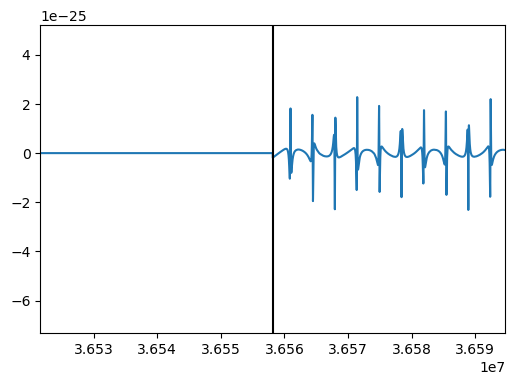

In [40]:
time = np.arange(len(emri_test)) * dt

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(time, emri_test.real.get())
ax.axvline(emri_waveform.initial_zeros_length*dt, color='black')

ax.set_xlim([0.999* emri_waveform.initial_zeros_length*dt, 1.001*emri_waveform.initial_zeros_length*dt])

In [41]:
2* ASTRONOMICAL_YEAR / dt

25246519.810836475

In [42]:
emri_waveform.initial_zeros_length

14623261

In [43]:
25246519.810836475 - 14623261*2

-4000002.1891635247

### Strain comparison
Compare generated strains to the ones generated by mojito light pipeline

In [39]:
# Load strain
strains_path = '/scratch/leuven/367/vsc36785/MojitoLight/SIM_data/brickmarket/mojito_light_v1_0_0/data/EMRI/strains'
strain = np.load(f'{strains_path}/emri_000{source_index}_strain.npz')

In [40]:
mojito_strain = strain['hplus']
mojito_strain

array([-1.82252342e-23, -1.81904858e-23, -1.81570245e-23, ...,
        1.97905288e-22,  1.97905288e-22,  1.97905288e-22],
      shape=(25246519,))

In [50]:
## slice the strain geenrated by custom emri object
emri_waveform_strain = EMRIWave(use_gpu=use_gpu, 
                         T_smooth=t_smooth, 
                         model=waveform_model,
                         mode_selection_threshold=mode_selection_threshold,
                         strain_only=True,
                         t0_orbits=t0_orbits,
                         t_init=t_init,
                         dt=dt, 
                         n_samples=n_samples,
                         offset=offset, # seconds
                         time=Time   # time for which we generate the waveform
                        )

In [51]:
strain_notebook_sliced = emri_waveform_strain(*params_mojito, dt=2.5)

In [52]:
emri_waveform.initial_zeros_length

14623140

In [53]:
strain_notebook_sliced

array([-1.82252342e-23-1.32506348e-24j, -1.81904858e-23-1.20713564e-24j,
       -1.81570245e-23-1.09027003e-24j, ...,
       -0.00000000e+00+0.00000000e+00j, -0.00000000e+00+0.00000000e+00j,
       -0.00000000e+00+0.00000000e+00j], shape=(25246520,))

In [54]:
time = np.arange(len(strain_notebook_sliced))*dt

(57519500.0, 57520000.0)

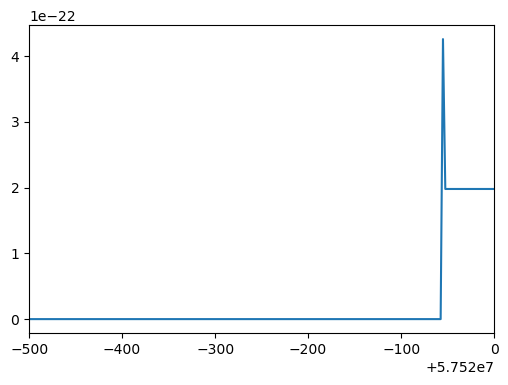

In [62]:
# plot()
fig, ax = plt.subplots(1,1, figsize=(6,4))

# ax.plot(time, strain_notebook_sliced.real.get(), label='notebook')
# ax.plot(time[:-1], mojito_strain.real, label='mojito')
ax.plot(time[:-1], mojito_strain.real - strain_notebook_sliced[:-1].real.get(), label='residual')
ax.set_xlim([5.75195e7, 5.752e7])


### Response comparison

In [44]:
# create orbits module
import os
home_folder = os.getcwd()
dense_orbit_file = f'{home_folder}/orbits/esa_trailing_densely_sampled.h5'

esa = Orbits(filename=orbit_file, 
            use_gpu=use_gpu, 
            force_backend=force_backend, 
            linear_interp_setup=False)

In [96]:
# create hacked orbits object
esa_hacked = Orbits(filename=orbit_file,
                    use_gpu=use_gpu, 
                    force_backend=force_backend, 
                    linear_interp_setup=False)
esa_hacked.configured

False

In [97]:
# Define the rotation matrix from ICRS (equatorial) to Ecliptic
epsilon = np.radians(23.439291)
R_icrs_to_ecl = np.array([
    [1, 0, 0],
    [0, np.cos(epsilon), np.sin(epsilon)],
    [0, -np.sin(epsilon), np.cos(epsilon)]
])

# positions: x_base has shape (N, 3, 3) = (time, spacecraft, xyz)
x_icrs = esa_hacked.x_base
x_ecl = np.einsum('ij,tkj->tki', R_icrs_to_ecl, x_icrs)

# velocities: v_base has shape (N, 3, 3)
v_icrs = esa_hacked.v_base
v_ecl = np.einsum('ij,tkj->tki', R_icrs_to_ecl, v_icrs)

# normal vectors: n_base has shape (N, 6, 3) = (time, links, xyz)
n_icrs = esa_hacked.n_base
n_ecl = np.einsum('ij,tlj->tli', R_icrs_to_ecl, n_icrs)

# Override the _base properties for x, v, n
class EclipticOrbits(type(esa_hacked)):
    '''
    Create subclass to override the initial ICRS frame atributes
    '''
    def __init__(self, base_orbits, x_ecl, v_ecl, n_ecl):
        # Copy all attributes from base
        self.__dict__.update(base_orbits.__dict__)
        self._x_ecl = x_ecl
        self._v_ecl = v_ecl
        self._n_ecl = n_ecl
        self._base_orbits = base_orbits
    
    @property
    def x_base(self):
        return self._x_ecl
    
    @property
    def v_base(self):
        return self._v_ecl
    
    @property
    def n_base(self):
        return self._n_ecl
    
    # Delegate other _base properties to original
    @property
    def ltt_base(self):
        return self._base_orbits.ltt_base
    
    @property
    def t_base(self):
        return self._base_orbits.t_base

# Create the ecliptic-transformed orbits
orbits_ecl = object.__new__(EclipticOrbits)
EclipticOrbits.__init__(orbits_ecl, esa_hacked, x_ecl, v_ecl, n_ecl)

# Now configure and use
orbits_ecl.configure(linear_interp_setup=True)

In [98]:
T = Time + 2 *  emri_waveform.initial_zeros_length *dt /ASTRONOMICAL_YEAR

In [99]:
type(params_mojito)

list

In [102]:
emri_params = [
    params['PrimaryMassSSBFrame'],
    params['SecondaryMassSSBFrame'],
    params['PrimarySpinParameter'],
    params['SemiLatusRectum'],
    params['Eccentricity'],
    np.cos(params['InclinationAngle']),
    params['LuminosityDistance']*1e-3,
    qS_ecl,
    phiS_ecl,
    params['PolarAnglePrimarySpin'],
    params['AzimuthalAnglePrimarySpin'],
    params['AzimuthalPhase'],
    params['PolarPhase'],
    params['RadialPhase'],
]

emri_params.append(qS_ecl)
emri_params.append(phiS_ecl)
index_lambda=14
index_beta=15

In [103]:
print(emri_params)

[np.float64(399143.8370943168), np.float64(36.7297320658767), np.float64(0.9689), np.float64(16.830469020340093), np.float64(0.7694807418917016), np.float64(1.0), np.float64(3.7141219594547703), np.float64(2.294777772454727), np.float64(1.9651857585886416), np.float64(1.2353252606186405), np.float64(5.501703732600556), np.float64(0.9670255899837221), np.float64(0.9967613024379192), np.float64(1.2776797663052248), np.float64(2.294777772454727), np.float64(1.9651857585886416)]


In [104]:
len(emri_params)

16

In [105]:
emri_TDI_list = ResponseWrapper(
    emri_waveform,
    T,
    dt,
    index_lambda,
    index_beta,
    t0=t0,
    flip_hx=True,  # set to True if waveform is h+ - ihx
    force_backend=force_backend,
    remove_sky_coords=True,  # True if the waveform generator does not take sky coordinates
    is_ecliptic_latitude=False,  # False if using polar angle (theta)
    remove_garbage=False,  # removes the beginning of the signal that has bad information
    orbits=esa_hacked,
    **tdi_kwargs,
)

In [106]:
def emri_TDI(*params):
    start_flr = emri_waveform.initial_zeros_length
    return cp.asarray(emri_TDI_list(*params))[:, start_flr:-start_flr]

In [107]:
len(emri_params)

16

In [108]:
chans = emri_TDI(*emri_params)

In [109]:
time = np.arange(len(chans[0])) * dt / YRSID_SI

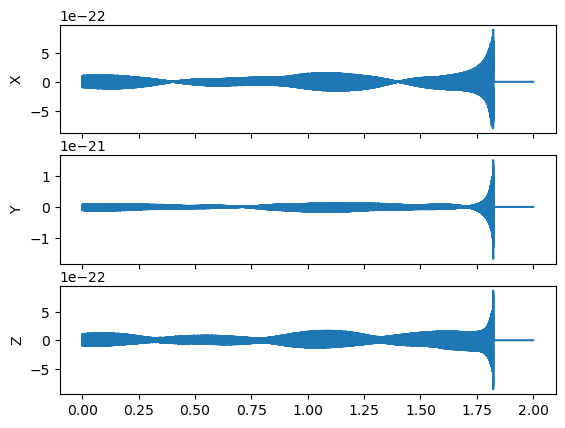

In [110]:
fig, ax = plt.subplots(3, 1, sharex=True)

for i, lab in enumerate(["X", "Y", "Z"]):
    ax[i].plot(time[::10], chans[i].get()[::10])
    # ax[i].set_xlim([1.999, 2.001])
    ax[i].set_ylabel(lab)

#### Inspect TDI channels: source 7

In [111]:
time_sim_L1 = np.arange(t0_l0+322.5, x2.shape[0]*delta_t + t0_l0+322.5, dt)[:-1] / YRSID_SI 
time_flr_L1 = np.arange(t0_orbits + emri_waveform.initial_zeros_length*dt, chans.shape[1]*delta_t + t0_orbits + emri_waveform.initial_zeros_length*dt - dt, dt) /YRSID_SI

In [112]:
time_sim_L1.shape

(25246480,)

In [113]:
time_flr_L1.shape

(25248920,)

In [114]:
(25248921 - 25246480)* 2.5

6102.5

In [115]:
emri_waveform.initial_zeros_length

14623261

Text(0.5, 1.0, 'TDI X channel')

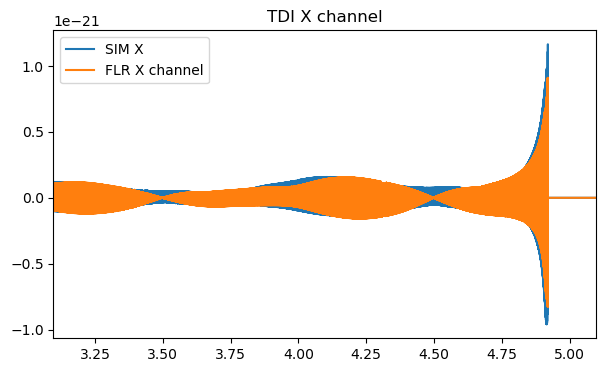

In [116]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_sim_L1, x2, label='SIM X')   
ax.plot(time_flr_L1, chans[0].get(), label='FLR X channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

Text(0.5, 1.0, 'TDI Y channel')

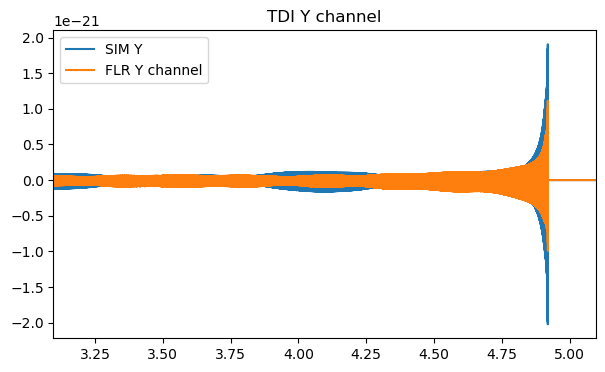

In [92]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, y2, label='SIM Y')   
ax.plot(time_flr_L1, chans[1].get(), label='FLR Y channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

Text(0.5, 1.0, 'TDI Z channel')

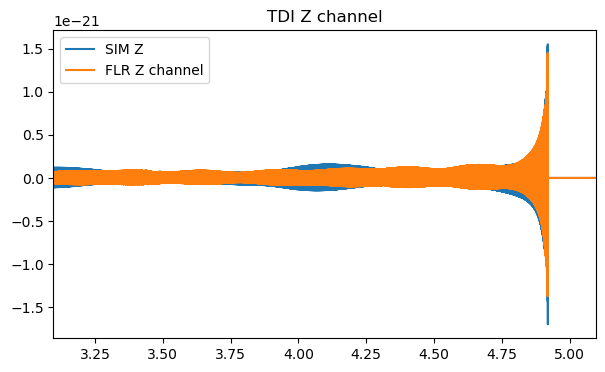

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.plot(time_sim_L1, z2, label='SIM Z')   
ax.plot(time_flr_L1, chans[2].get(), label='FLR Z channel')
ax.set_xlim([time_sim_L1[0], time_sim_L1[-1]])
ax.legend(loc='upper left')
ax.set_title('TDI Z channel')

In [72]:
time_flr_L1

array([3.0968036 , 3.09680368, 3.09680376, ..., 5.0969935 , 5.09699358,
       5.09699366], shape=(25248920,))

In [73]:
time_sim_L1

array([3.09683118, 3.09683126, 3.09683134, ..., 5.09682779, 5.09682787,
       5.09682795], shape=(25246480,))

In [74]:
25248920 - 25246480

2440

In [75]:
(3.09683118 - 3.0968036)*ASTRONOMICAL_YEAR / dt

348.1495081945791

Text(0.5, 1.0, 'TDI X channel')

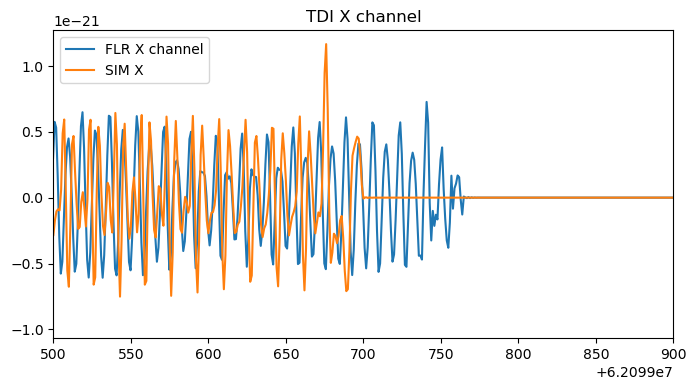

In [117]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))


ax.plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax.set_xlim([6.20995e7,6.20999e7 ])
ax.legend(loc='upper left')
ax.set_title('TDI X channel')

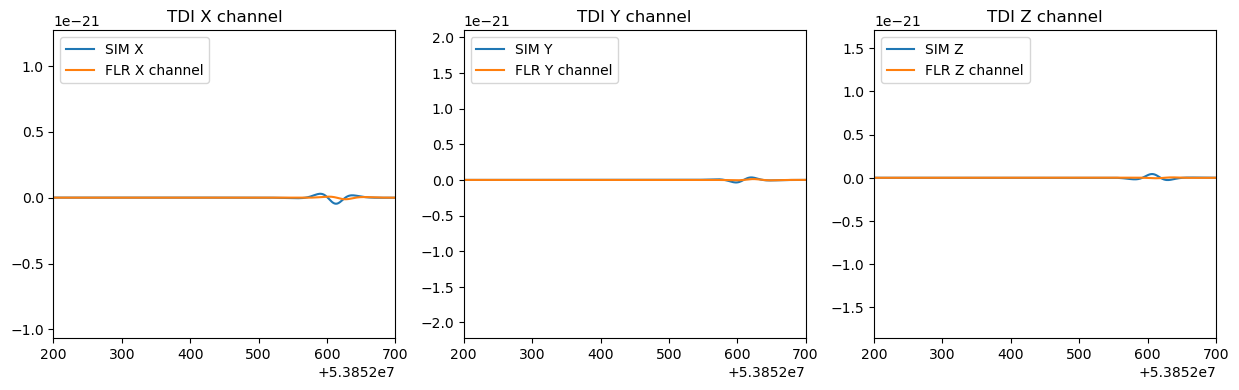

In [77]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1*YRSID_SI/dt, sim_data[i], label=f'SIM {lab}')   
    ax[i].plot(time_flr_L1*YRSID_SI/dt, chans[i].get(), label=f'FLR {lab} channel')
    ax[i].set_xlim([5.38522e7,5.38527e7 ])
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

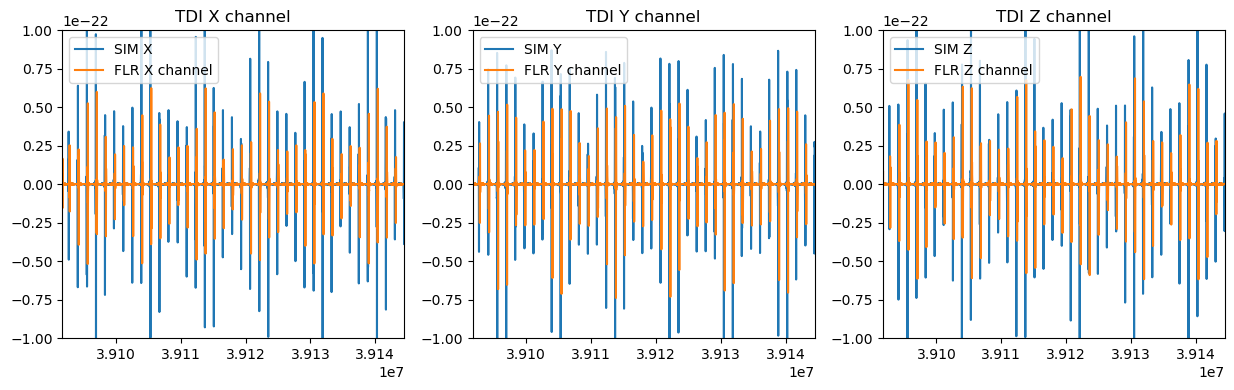

In [94]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = ['X', 'Y', 'Z']
sim_data = {0: x2, 1: y2, 2: z2}

for i, lab in enumerate(labels):
    ax[i].plot(time_sim_L1*YRSID_SI/dt, sim_data[i], label=f'SIM {lab}')   
    ax[i].plot(time_flr_L1*YRSID_SI/dt, chans[i].get(), label=f'FLR {lab} channel')
    ax[i].set_xlim([3.0968036 * YRSID_SI/dt, 3.0968036 * YRSID_SI/dt + 0.00527e7 ])
    ax[i].set_ylim([-1e-22, 1e-22])
    ax[i].legend(loc='upper left')
    
    ax[i].set_title(f'TDI {lab} channel')

In [96]:

print(len(sim_data[0]))
print(len(chans[i].get()))
min_len = min(len(sim_data[0]), len(chans[0].get()))

25246480
25248920


In [97]:
# window and fft signals
wd_tdi = cp.asarray(tukey(min_len, alpha=0.01))
flr_sliced = chans[:, :min_len]
X_sim_fft = cp.fft.rfft(cp.asarray(x2) * wd_tdi)[1:]
X_flr_fft = cp.fft.rfft(flr_sliced[0] * wd_tdi)[1:]

freq_L1 = cp.fft.rfftfreq(len(wd_tdi), dt)

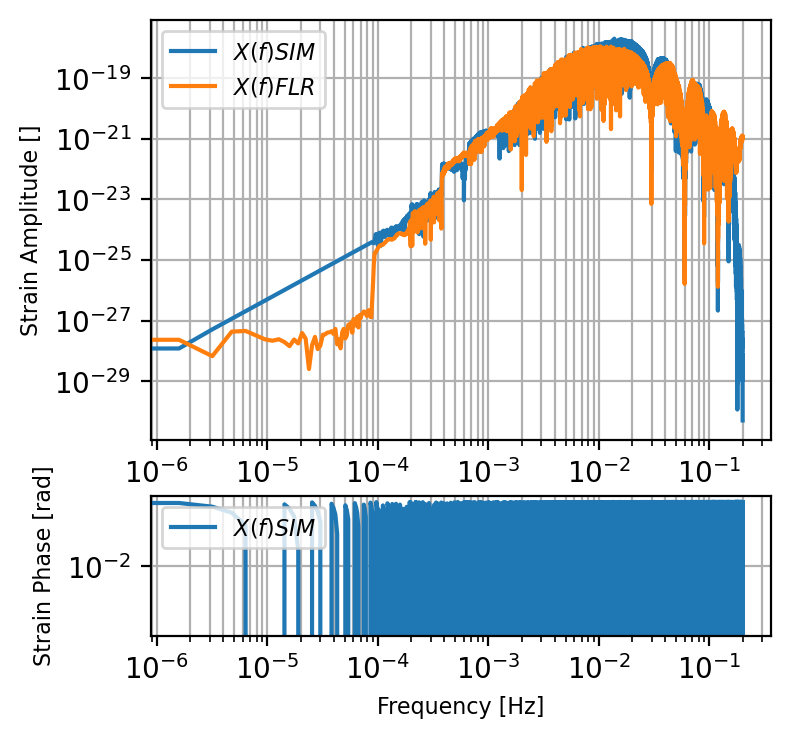

In [98]:
# Comparison in frequency domain
FontSize = 8
DecimFactor = 100
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4,4), dpi=200, gridspec_kw={'height_ratios': [3, 1]})
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(X_sim_fft[::DecimFactor].get()), label='$X(f) SIM$')
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(X_flr_fft[::DecimFactor].get()), label='$X(f) FLR$')
# axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(residual[::DecimFactor].get()), label='$X(f) residual$')
axs[0].legend(fontsize=FontSize, loc='upper left')
axs[0].grid(visible=True, which='both')
axs[0].set_xlabel('Frequency [Hz]', fontsize=FontSize);
axs[0].set_ylabel('Strain Amplitude []', fontsize=FontSize);

# axs[0].set_xlim([fmin, fmax]);
# axs[0].set_ylim([0.1*np.min(np.abs(T_fft[freq_L1 >= fmin])),
#                  10*np.max(np.abs(A_fft[freq_L1 <= fmax]))]);

axs[1].loglog(freq_L1[::DecimFactor].get(), np.angle(X_sim_fft[::DecimFactor].get()), label='$X(f) SIM$')
# axs[1].loglog(freq_L1[::DecimFactor].get(), np.angle(X_flr_fft[::DecimFactor].get()), label='$X(f) FLR$')
# axs[1].loglog(freq_L1[::DecimFactor], np.angle(T_fft[::DecimFactor]), label='$T(f)$')

axs[1].legend(fontsize=FontSize, loc='upper left')
axs[1].grid(visible=True, which='both')

axs[1].set_xlabel('Frequency [Hz]', fontsize=FontSize);
axs[1].set_ylabel('Strain Phase [rad]', fontsize=FontSize);

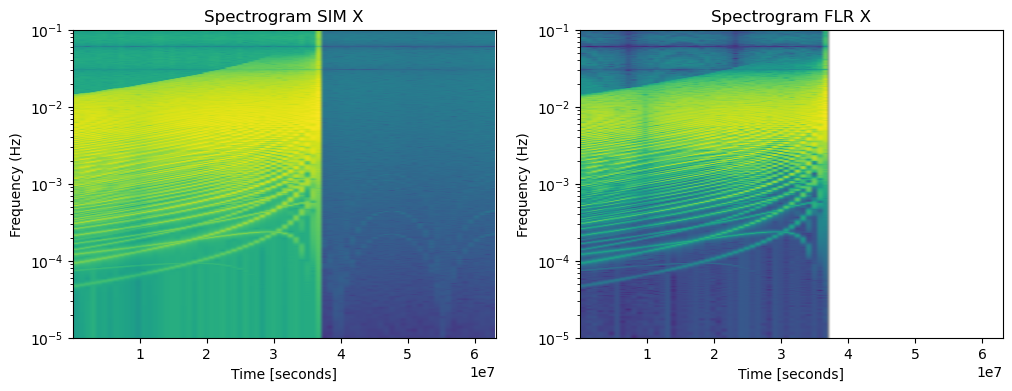

In [84]:
# Make spectrograms
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].set_title('Spectrogram SIM X')
Pxx, freqs, bins, im = ax[0].specgram(x2, 
                                    NFFT=time_sim_L1.size//75, 
                                    Fs=1/dt)
ax[1].set_title('Spectrogram FLR X')
Pxx, freqs, bins, im = ax[1].specgram(flr_sliced[0].get(), 
                                    NFFT=time_sim_L1.size//75, 
                                    Fs=1/dt)

'''
The `specgram` method returns 4 objects. They are:
   - Pxx: the periodogram
   - freqs: the frequency vector
   - bins: the centers of the time bins
   - im: the .image.AxesImage instance representing the data in the plot
'''


for i in range(2):
    ax[i].set_yscale('log')
    ax[i].set_ylim(1e-5, 1e-1)
    ax[i].set_xlabel('Time [seconds]')
    ax[i].set_ylabel('Frequency (Hz)')

### Inspect TDI channels: source 7

In [ ]:
# Load source 7 data

Text(0.5, 1.0, 'TDI X channel')

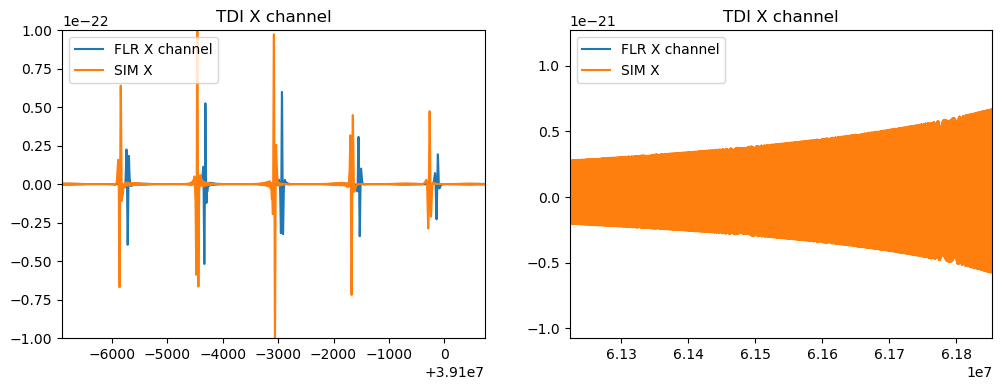

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# b = 0.0061

ax[0].plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax[0].plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax[0].set_xlim([(time_sim_L1[0])*YRSID_SI/dt+1000, (time_sim_L1[0]+ 0.00005)*YRSID_SI/dt+8000])
ax[0].set_ylim([-1e-22, 1e-22])
ax[0].legend(loc='upper left')
ax[0].set_title('TDI X channel')

ax[1].plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax[1].plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax[1].set_xlim([(4.85)*YRSID_SI/dt, (4.90)*YRSID_SI/dt])
ax[1].legend(loc='upper left')
ax[1].set_title('TDI X channel')

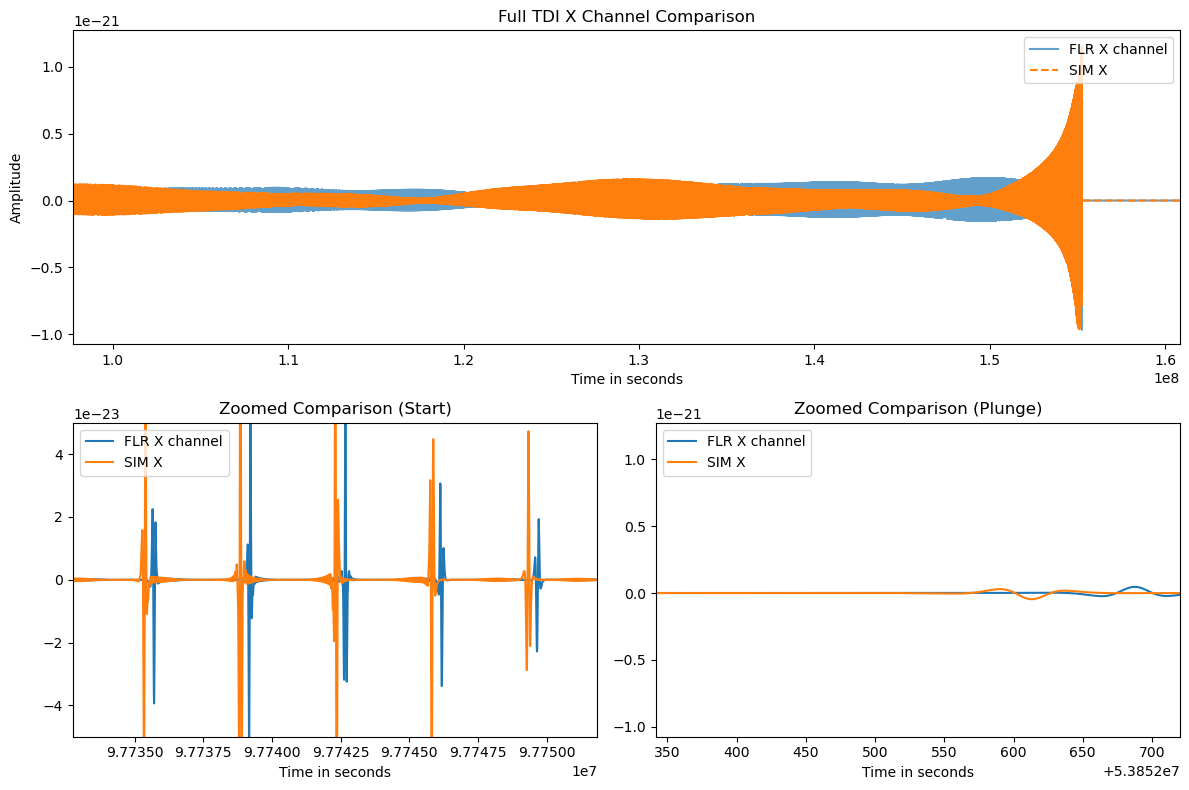

In [100]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2)

# panel with full thing
ax_top = fig.add_subplot(gs[0, :]) # Spans row 0, all columns
ax_top.plot(time_flr_L1*YRSID_SI, chans[0].get(), label='FLR X channel', alpha=0.7)
ax_top.plot(time_sim_L1*YRSID_SI, x2, label='SIM X', linestyle='--')
ax_top.set_xlim([time_sim_L1[0]*YRSID_SI, time_sim_L1[-1]*YRSID_SI])
ax_top.set_title('Full TDI X Channel Comparison')
ax_top.legend(loc='upper right')
ax_top.set_xlabel('Time in seconds')
ax_top.set_ylabel('Amplitude')

# bottom left
ax_left = fig.add_subplot(gs[1, 0])
ax_left.plot(time_flr_L1*YRSID_SI, chans[0].get(), label='FLR X channel')
ax_left.plot(time_sim_L1*YRSID_SI, x2, label='SIM X')   
ax_left.set_xlim([(time_sim_L1[0])*YRSID_SI+1000*dt, (time_sim_L1[0]+ 0.00005)*YRSID_SI+8000*dt])
ax_left.set_ylim([-5e-23, 5e-23])
ax_left.legend(loc='upper left')
ax_left.set_xlabel('Time in seconds')
ax_left.set_title('Zoomed Comparison (Start)')

# Bottom right
ax_right = fig.add_subplot(gs[1, 1])
ax_right.plot(time_flr_L1*YRSID_SI/dt, chans[0].get(), label='FLR X channel')
ax_right.plot(time_sim_L1*YRSID_SI/dt, x2, label='SIM X')   
ax_right.set_xlim([(4.26612)*YRSID_SI/dt, (4.26615)*YRSID_SI/dt])
ax_right.legend(loc='upper left')
ax_right.set_xlabel('Time in seconds')
ax_right.set_title('Zoomed Comparison (Plunge)')

plt.tight_layout()
plt.show()

In [60]:
# slice fastlisaresponse array at correct value
start_SIM = time_sim_L1[0]
start_flr = time_flr_L1[0]
start_ind = int((start_SIM - start_flr)*YRSID_SI/dt)
start_ind

14623609

In [61]:
flr_sliced = chans[:, start_ind:len(x2)+start_ind]
flr_sliced.shape

(3, 25246480)

In [62]:
x2.shape

(25246480,)

In [63]:
wd_tdi =  cp.asarray(tukey(x2.shape[0], alpha=0.9, sym=True))
X_sim_fft = cp.fft.rfft(cp.asarray(x2) * wd_tdi)[1:]
X_flr_fft = cp.fft.rfft(flr_sliced[0] * wd_tdi)[1:]

residual = cp.fft.rfft((cp.asarray(x2) -flr_sliced[0]) * wd_tdi)[1:]
# T_fft = np.fft.rfft(T_ts * wd_tdi)[1:]
freq_L1 = cp.fft.rfftfreq(wd_tdi.size, d=delta_t)[1:]

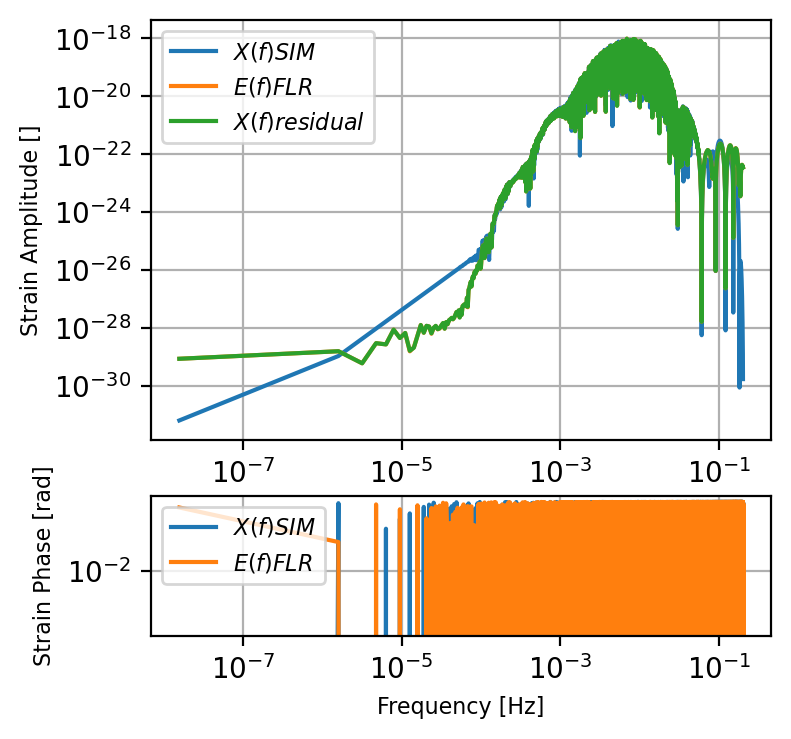

In [64]:
# Comparison in frequency domain
FontSize = 8
DecimFactor = 100
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4,4), dpi=200, gridspec_kw={'height_ratios': [3, 1]})
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(X_sim_fft[::DecimFactor].get()), label='$X(f) SIM$')
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(X_flr_fft[::DecimFactor].get()), label='$X(f) FLR$')
axs[0].loglog(freq_L1[::DecimFactor].get(), np.abs(residual[::DecimFactor].get()), label='$X(f) residual$')
axs[0].legend(fontsize=FontSize, loc='upper left')
axs[0].grid(visible=True, which='both')
axs[0].set_xlabel('Frequency [Hz]', fontsize=FontSize);
axs[0].set_ylabel('Strain Amplitude []', fontsize=FontSize);

# axs[0].set_xlim([fmin, fmax]);
# axs[0].set_ylim([0.1*np.min(np.abs(T_fft[freq_L1 >= fmin])),
#                  10*np.max(np.abs(A_fft[freq_L1 <= fmax]))]);

axs[1].loglog(freq_L1[::DecimFactor].get(), np.angle(X_sim_fft[::DecimFactor].get()), label='$X(f) SIM$')
axs[1].loglog(freq_L1[::DecimFactor].get(), np.angle(X_flr_fft[::DecimFactor].get()), label='$X(f) FLR$')
# axs[1].loglog(freq_L1[::DecimFactor], np.angle(T_fft[::DecimFactor]), label='$T(f)$')

axs[1].legend(fontsize=FontSize, loc='upper left')
axs[1].grid(visible=True, which='both')

axs[1].set_xlabel('Frequency [Hz]', fontsize=FontSize);
axs[1].set_ylabel('Strain Phase [rad]', fontsize=FontSize);

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[1].get(), label='FLR Y')
ax.plot(time_sim_L1, Y_sin, label='SIM Y')   

ax.legend(loc='upper left')
ax.set_title('TDI Y channel')

NameError: name 'Y_sin' is not defined

Text(0.5, 1.0, 'TDI Z channel')

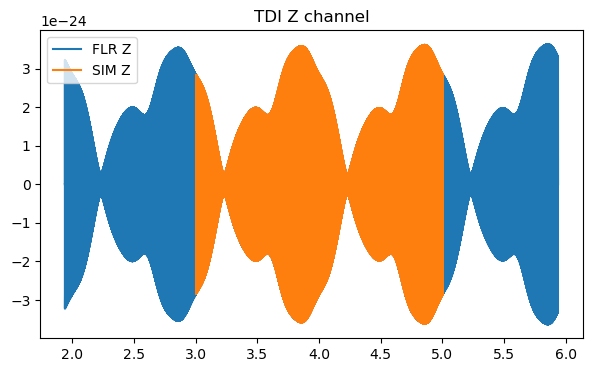

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.plot(time_flr_L1, chans[2].get(), label='FLR Z')
ax.plot(time_sim_L1, Z_sin, label='SIM Z')   

ax.legend(loc='upper left')
ax.set_title('TDI Z channel')

#### Inspect single link responses

In [47]:
y_flr = emri_TDI_list.response_model.y_gw

In [48]:
T_DLTT_ORBITS = 10.
with File(orbit_file, 'r') as f:
    t0_orbits = f.attrs['t_start'] + T_DLTT_ORBITS

In [49]:
# comparison plots
time_sim_L0 = np.arange(l01_t0, y_ts.shape[0]*delta_t + l01_t0, dt)[:-1] / YRSID_SI 
time_flr_L0 = np.arange(t0_orbits, y_flr.shape[1]*delta_t + t0_orbits, dt)[:-1] /YRSID_SI

NameError: name 'l01_t0' is not defined

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(2):
    for l in range(3):
        b = k * 3 + l
        print(b)
        axes[k, l].plot(time_flr_L0[:-1000][::10], y_flr[b, :-1000].get()[::10], label='L0 flr')
        axes[k, l].plot(time_sim_L0[:-1000][::10], y_ts[:-1000, b][::10], label=f'L0 sim')
      
        axes[k, l].set_xlabel('Time [years]')
        axes[k, l].legend(loc='upper right')
        axes[k, l].set_title(f'Link response {LINKS[b]}, b = {b}')
        
fig.suptitle('Individual link responses: SIM vs FLR', fontsize=19)
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for k in range(2):
    for l in range(3):
        b = k * 3 + l
        # print(b)
        starting = 200000
        axes[k, l].plot(time_sim_L0[:-1000][::10], y_ts[:-1000, b][::10], label=f'L0 sim')
        axes[k, l].plot(time_flr_L0[:-1000][::10], y_flr[b, :-1000].get()[::10], label='L0 flr')
        
        # axes[k, l].plot(time_sim_L0[:-1000][::10], y_flr[b, :-1000].get()[::10][] - y_ts[:-1000, b][::10], label=f'Residual')
        axes[k, l].set_xlim([time_sim_L0[0+starting], time_sim_L0[starting+ 1000]])
        axes[k, l].set_xlabel('Time [years]')
        axes[k, l].legend(loc='upper right')
        axes[k, l].set_title(f'Link response {LINKS[b]}, b = {b}')
        
fig.suptitle('Individual link responses: SIM vs FLR', fontsize=19)
plt.tight_layout()